<a href="https://colab.research.google.com/github/M4XJUNG/AIF-Financial-Time-Series/blob/main/M4_N_BEATS_Time_o1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# (추가) GPU에서 “가능한 한” 결과 고정시키는 셀 (원하면 맨 위에 1회만)
import os, random
import numpy as np
import torch

seed = 42
os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# 아래는 일부 연산에서 에러 날 수 있음(그럼 주석 처리)
# torch.use_deterministic_algorithms(True)


In [2]:
# 셀 1) 프로젝트 폴더 만들기 + M4 Finance Daily를 “long format”으로 준비
import os, sys, subprocess
from pathlib import Path
import pandas as pd
import numpy as np

PROJ = Path("/content/m4_nbeats_timeo1")
for p in ["data", "artifacts", "logs"]:
    os.makedirs(PROJ / p, exist_ok=True)

base = "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset"
info = pd.read_csv(f"{base}/M4-info.csv")

FREQ = "Daily"   # 너가 이미 Daily Finance로 했으니 일단 Daily 유지
H = 14          # M4 Daily horizon
finance_ids = info[(info["category"]=="Finance") & (info["SP"]==FREQ)]["M4id"].tolist()

train = pd.read_csv(f"{base}/Train/{FREQ}-train.csv").rename(columns={"V1":"unique_id"})
test  = pd.read_csv(f"{base}/Test/{FREQ}-test.csv").rename(columns={"V1":"unique_id"})

train = train[train["unique_id"].isin(finance_ids)].reset_index(drop=True)
test  = test[test["unique_id"].isin(finance_ids)].reset_index(drop=True)

print("Finance Daily:", train.shape, test.shape)

# wide -> long (unique_id, ds, y)
def wide_to_long(df_wide):
    df = df_wide.copy()
    vals = df.drop(columns=["unique_id"]).to_numpy()
    out = []
    for i, uid in enumerate(df["unique_id"].tolist()):
        y = vals[i]
        y = y[~np.isnan(y)]
        # ds는 단순 index로 두고, 모델에서 freq 의미만 맞추면 됨(일단 smoke)
        out.append(pd.DataFrame({"unique_id": uid, "ds": np.arange(len(y), dtype=int), "y": y.astype(np.float32)}))
    return pd.concat(out, axis=0, ignore_index=True)

df_train_long = wide_to_long(train)
# test는 미래 H만 있으니, 평가 때만 따로 사용(OWA 계산용)
df_train_long.to_parquet(PROJ/"data"/"m4_fin_daily_train_long.parquet", index=False)

(train[["unique_id"]]).to_csv(PROJ/"data"/"finance_daily_ids.csv", index=False)
test.to_parquet(PROJ/"data"/"m4_fin_daily_test_wide.parquet", index=False)

print("saved:",
      PROJ/"data"/"m4_fin_daily_train_long.parquet",
      PROJ/"data"/"m4_fin_daily_test_wide.parquet")


Finance Daily: (1559, 9920) (1559, 15)
saved: /content/m4_nbeats_timeo1/data/m4_fin_daily_train_long.parquet /content/m4_nbeats_timeo1/data/m4_fin_daily_test_wide.parquet


In [3]:
# 셀 2) “loss 플러그인” 준비
import torch
import torch.nn.functional as F

def time_o1_loss(y_hat, y, alpha=0.5, gamma=0.5, eps=1e-6):
    """
    Time-o1 알고리즘(요지):
    - 정답 레이블 y를 표준화(평균0, 표준편차1)
    - y의 시간축 상관구조를 SVD로 뽑아(사실상 PCA)
    - 그 변환 공간에서 상위 K개 성분만 맞추도록 L1 손실 추가
    - 기존 시간영역 MSE(TMSE)와 가중합해서 학습 안정/자기상관 반영을 노림

    입력:
      y_hat, y: (배치, horizon)  단변량 예측값/정답
      alpha: 변환공간 손실 비중
      gamma: horizon에서 몇 개 성분(K)을 쓸지 비율
    """
    assert y_hat.shape == y.shape and y.dim() == 2, (y_hat.shape, y.shape)

    B, H = y.shape
    K = max(1, int(round(gamma * H)))

    # (1) y 기준으로 표준화(누수/불안정 방지: y_hat도 동일 mu/sigma로 표준화)
    mu = y.mean(dim=1, keepdim=True)
    sig = y.std(dim=1, keepdim=True).clamp_min(eps)
    y_std = (y - mu) / sig
    yhat_std = (y_hat - mu) / sig

    # (2) SVD로 변환 기저 P* 계산 (시간축 상관구조)
    _, _, Vh = torch.linalg.svd(y_std, full_matrices=False)
    P = Vh.transpose(-2, -1)  # (H, H)

    # (3) 변환 공간으로 투영
    Z = y_std @ P
    Zhat = yhat_std @ P

    # (4) 상위 K개 성분 L1 + 시간영역 MSE 결합
    l_trans = torch.abs(Zhat[:, :K] - Z[:, :K]).mean()
    l_tmse = F.mse_loss(y_hat, y)
    return alpha * l_trans + (1.0 - alpha) * l_tmse


In [4]:
B, H = 32, 14
y = torch.randn(B, H)
y_hat = y + 0.1 * torch.randn(B, H)
loss = time_o1_loss(y_hat, y, alpha=0.5, gamma=0.5)
print(loss.item())


0.05014767125248909


In [5]:
# 셀 3) Naive2(비교 기준) 예측/지표 저장 + 공통 metric 함수
import os, json
from pathlib import Path
import numpy as np
import pandas as pd

PROJ = Path("/content/m4_nbeats_timeo1")
DATA = PROJ / "data"
ART  = PROJ / "artifacts"
LOG  = PROJ / "logs"
CKPT = PROJ / "checkpoints"
for p in [ART, LOG, CKPT]:
    os.makedirs(p, exist_ok=True)

FREQ = "Daily"
H = 14
m = 1  # M4 Daily는 seasonality=1로 처리

# 저장해둔 test_wide 사용
test = pd.read_parquet(DATA / "m4_fin_daily_test_wide.parquet")
ids = pd.read_csv(DATA / "finance_daily_ids.csv")["unique_id"].tolist()

# train은 wide 형태가 MASE scale 계산/Naive2에 편함 -> raw로 다시 받음(빠름)
base = "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset"
train_wide = pd.read_csv(f"{base}/Train/{FREQ}-train.csv").rename(columns={"V1": "unique_id"})
train_wide = train_wide[train_wide["unique_id"].isin(ids)].reset_index(drop=True)

assert train_wide.shape[0] == 1559 and test.shape[0] == 1559, (train_wide.shape, test.shape)

def row_to_series(row):
    x = row.iloc[1:].to_numpy(dtype=np.float32)
    return x[~np.isnan(x)]

def smape_mean(y, yhat, eps=1e-8):
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    num = np.abs(yhat - y)
    den = np.abs(y) + np.abs(yhat) + eps
    return float(200.0 * np.mean(num / den))

def mase_mean(insample_mat, y, yhat, m=1, eps=1e-8):
    # insample_mat: (N, T) NaN padding 가능
    insample_mat = np.asarray(insample_mat, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)

    diffs = np.abs(insample_mat[:, m:] - insample_mat[:, :-m])
    scale = np.nanmean(diffs, axis=1) + eps  # (N,)
    err = np.nanmean(np.abs(yhat - y), axis=1)  # (N,)
    return float(np.mean(err / scale))

def naive2_forecast(y_tr, h, m=1):
    y_tr = np.asarray(y_tr, dtype=np.float32)
    if y_tr.size == 0:
        return np.zeros(h, dtype=np.float32)
    if m > 1 and y_tr.size >= m:
        last = y_tr[-m:]
        reps = int(np.ceil(h / m))
        return np.tile(last, reps)[:h].astype(np.float32)
    return np.full(h, y_tr[-1], dtype=np.float32)

# y_true
y_true = test.drop(columns=["unique_id"]).to_numpy(dtype=np.float32)  # (1559, 14)

# insample matrix (MASE scale)
insample = train_wide.drop(columns=["unique_id"]).to_numpy(dtype=np.float32)  # (1559, T) + NaN

# naive2 preds
y_pred_n2 = np.zeros_like(y_true, dtype=np.float32)
for i, row in train_wide.iterrows():
    y_tr = row_to_series(row)
    y_pred_n2[i] = naive2_forecast(y_tr, H, m)

sm_n2 = smape_mean(y_true, y_pred_n2)
ma_n2 = mase_mean(insample, y_true, y_pred_n2, m=m)

naive2_metrics = {
    "dataset": "M4",
    "category": "Finance",
    "freq": FREQ,
    "N": int(y_true.shape[0]),
    "H": int(H),
    "m": int(m),
    "model": "Naive2",
    "sMAPE_mean": sm_n2,
    "MASE_mean": ma_n2,
    "OWA_vs_Naive2": 1.0,
}

np.savez_compressed(ART / "Daily_Finance_Naive2.npz",
                    ids=np.array(ids), y_true=y_true, y_pred=y_pred_n2)
(ART / "Daily_Finance_Naive2.json").write_text(json.dumps(naive2_metrics, indent=2), encoding="utf-8")

print(naive2_metrics)
print("saved:", ART / "Daily_Finance_Naive2.npz")
print("saved:", ART / "Daily_Finance_Naive2.json")


{'dataset': 'M4', 'category': 'Finance', 'freq': 'Daily', 'N': 1559, 'H': 14, 'm': 1, 'model': 'Naive2', 'sMAPE_mean': 3.517052389619388, 'MASE_mean': 3.5143761051316997, 'OWA_vs_Naive2': 1.0}
saved: /content/m4_nbeats_timeo1/artifacts/Daily_Finance_Naive2.npz
saved: /content/m4_nbeats_timeo1/artifacts/Daily_Finance_Naive2.json


In [6]:
# 셀 4) N-BEATS 학습(1) : TMSE baseline (로그/체크포인트 저장)
'''
여기서부터가 “벤치마크-베이스라인”의 딥러닝 파트
우선 smoke로 돌리기 위해 steps를 적게 잡았음. (원하면 steps만 늘리면 전량 학습으로 확장됨)
'''
import os, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

PROJ = Path("/content/m4_nbeats_timeo1")
DATA = PROJ / "data"
LOG  = PROJ / "logs"
CKPT = PROJ / "checkpoints"
os.makedirs(LOG, exist_ok=True)
os.makedirs(CKPT, exist_ok=True)

# ---- 하이퍼파라미터(일단 안정적으로 돌아가는 값) ----
INPUT_SIZE = 256
H = 14
BATCH_SIZE = 256
LR = 1e-3
EPOCHS = 2
STEPS_PER_EPOCH = 200   # ✅ smoke. 2000~10000으로 키우면 학습이 “진짜” 됨.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# ----------------------------------------------------

# train wide 다시 사용 (빠름)
base = "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset"
train_wide = pd.read_csv(f"{base}/Train/Daily-train.csv").rename(columns={"V1":"unique_id"})
ids = pd.read_csv(DATA / "finance_daily_ids.csv")["unique_id"].tolist()
train_wide = train_wide[train_wide["unique_id"].isin(ids)].reset_index(drop=True)

def row_to_series(row):
    x = row.iloc[1:].to_numpy(dtype=np.float32)
    return x[~np.isnan(x)]

series_list = [row_to_series(r) for _, r in train_wide.iterrows()]
lengths = np.array([len(x) for x in series_list], dtype=np.int32)

def sample_batch(batch_size, input_size, h):
    xs = np.zeros((batch_size, input_size), dtype=np.float32)
    ys = np.zeros((batch_size, h), dtype=np.float32)
    for i in range(batch_size):
        sid = np.random.randint(0, len(series_list))
        y = series_list[sid]
        L = y.shape[0]
        # 최소 input+h 확보 안 되면 패딩으로 처리
        if L < input_size + h + 1:
            pad_val = y[-1] if L > 0 else 0.0
            y_pad = np.pad(y, (input_size + h + 1 - L, 0), mode="constant", constant_values=pad_val)
            y = y_pad
            L = y.shape[0]
        t = np.random.randint(input_size, L - h)  # 예측 시작점
        x_raw = y[t - input_size: t]
        y_raw = y[t: t + h]

        mu = x_raw.mean()
        sig = x_raw.std() + 1e-6

        xs[i] = (x_raw - mu) / sig
        ys[i] = (y_raw - mu) / sig
    return torch.from_numpy(xs), torch.from_numpy(ys)

class NBeatsBlock(nn.Module):
    def __init__(self, input_size, theta_size, hidden_size=512, n_layers=4):
        super().__init__()
        layers = []
        in_dim = input_size
        for _ in range(n_layers):
            layers.append(nn.Linear(in_dim, hidden_size))
            layers.append(nn.ReLU())
            in_dim = hidden_size
        self.fc = nn.Sequential(*layers)
        self.theta = nn.Linear(hidden_size, theta_size)

    def forward(self, x):
        h = self.fc(x)
        return self.theta(h)

class NBeats(nn.Module):
    def __init__(self, input_size, h, n_blocks=8, hidden_size=512, n_layers=4):
        super().__init__()
        self.input_size = input_size
        self.h = h
        self.blocks = nn.ModuleList([
            NBeatsBlock(input_size, theta_size=input_size + h, hidden_size=hidden_size, n_layers=n_layers)
            for _ in range(n_blocks)
        ])

    def forward(self, x):
        # x: (B, input_size)
        residual = x
        forecast = x.new_zeros((x.size(0), self.h))
        for blk in self.blocks:
            theta = blk(residual)
            backcast = theta[:, : self.input_size]
            fcst = theta[:, self.input_size :]
            residual = residual - backcast
            forecast = forecast + fcst
        return forecast

# TMSE loss
def tmse_loss(y_hat, y):
    return F.mse_loss(y_hat, y)

# 로깅
log_path = LOG / "train_nbeats_tmse.log"
def log(msg):
    s = f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] {msg}"
    print(s)
    with open(log_path, "a", encoding="utf-8") as f:
        f.write(s + "\n")

torch.manual_seed(42)
np.random.seed(42)

model = NBeats(INPUT_SIZE, H, n_blocks=8, hidden_size=512, n_layers=4).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LR)
from torch.amp import GradScaler, autocast
use_amp = (DEVICE == "cuda")
scaler = GradScaler(enabled=use_amp)


log(f"DEVICE={DEVICE} N={len(series_list)} INPUT_SIZE={INPUT_SIZE} H={H} BATCH={BATCH_SIZE} EPOCHS={EPOCHS} STEPS_PER_EPOCH={STEPS_PER_EPOCH}")

model.train()
for ep in range(1, EPOCHS + 1):
    losses = []
    t0 = time.time()
    for step in range(1, STEPS_PER_EPOCH + 1):
        x, y = sample_batch(BATCH_SIZE, INPUT_SIZE, H)
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        opt.zero_grad(set_to_none=True)
        with autocast(device_type="cuda", enabled=use_amp):
            y_hat = model(x)
            loss = tmse_loss(y_hat, y)


        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt)
        scaler.update()

        losses.append(loss.item())

        if step % 50 == 0:
            log(f"ep={ep} step={step}/{STEPS_PER_EPOCH} loss={np.mean(losses[-50:]):.6f}")

    log(f"ep={ep} done avg_loss={np.mean(losses):.6f} time={time.time()-t0:.1f}s")

ckpt_path = CKPT / "nbeats_tmse.pt"
torch.save({"model": model.state_dict(),
            "input_size": INPUT_SIZE,
            "h": H}, ckpt_path)
log(f"saved checkpoint: {ckpt_path}")

# tail 출력
print("\n--- log tail ---")
print("\n".join(open(log_path, "r", encoding="utf-8").read().splitlines()[-20:]))


[2026-02-22 15:07:23] DEVICE=cuda N=1559 INPUT_SIZE=256 H=14 BATCH=256 EPOCHS=2 STEPS_PER_EPOCH=200
[2026-02-22 15:07:26] ep=1 step=50/200 loss=408.381906
[2026-02-22 15:07:27] ep=1 step=100/200 loss=574.686790
[2026-02-22 15:07:29] ep=1 step=150/200 loss=0.378797
[2026-02-22 15:07:30] ep=1 step=200/200 loss=293.246529
[2026-02-22 15:07:30] ep=1 done avg_loss=319.173506 time=6.7s
[2026-02-22 15:07:32] ep=2 step=50/200 loss=0.405154
[2026-02-22 15:07:33] ep=2 step=100/200 loss=0.322712
[2026-02-22 15:07:35] ep=2 step=150/200 loss=269.651040
[2026-02-22 15:07:37] ep=2 step=200/200 loss=25.799226
[2026-02-22 15:07:37] ep=2 done avg_loss=74.044533 time=6.7s
[2026-02-22 15:07:37] saved checkpoint: /content/m4_nbeats_timeo1/checkpoints/nbeats_tmse.pt

--- log tail ---
[2026-02-22 15:07:23] DEVICE=cuda N=1559 INPUT_SIZE=256 H=14 BATCH=256 EPOCHS=2 STEPS_PER_EPOCH=200
[2026-02-22 15:07:26] ep=1 step=50/200 loss=408.381906
[2026-02-22 15:07:27] ep=1 step=100/200 loss=574.686790
[2026-02-22 15:0

In [7]:
# 셀 5) N-BEATS 평가 + OWA 계산 + 예측 저장 (TMSE 버전)
import os, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

PROJ = Path("/content/m4_nbeats_timeo1")
DATA = PROJ / "data"
ART  = PROJ / "artifacts"
LOG  = PROJ / "logs"
CKPT = PROJ / "checkpoints"
for p in [ART, LOG, CKPT]:
    os.makedirs(p, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 공통 metric 로드
naive2_metrics = json.loads((ART / "Daily_Finance_Naive2.json").read_text(encoding="utf-8"))
sm_n2 = naive2_metrics["sMAPE_mean"]
ma_n2 = naive2_metrics["MASE_mean"]

test = pd.read_parquet(DATA / "m4_fin_daily_test_wide.parquet")
ids = pd.read_csv(DATA / "finance_daily_ids.csv")["unique_id"].tolist()

base = "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset"
train_wide = pd.read_csv(f"{base}/Train/Daily-train.csv").rename(columns={"V1":"unique_id"})
train_wide = train_wide[train_wide["unique_id"].isin(ids)].reset_index(drop=True)

def row_to_series(row):
    x = row.iloc[1:].to_numpy(dtype=np.float32)
    return x[~np.isnan(x)]

def smape_mean(y, yhat, eps=1e-8):
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    num = np.abs(yhat - y)
    den = np.abs(y) + np.abs(yhat) + eps
    return float(200.0 * np.mean(num / den))

def mase_mean(insample_mat, y, yhat, m=1, eps=1e-8):
    insample_mat = np.asarray(insample_mat, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    diffs = np.abs(insample_mat[:, m:] - insample_mat[:, :-m])
    scale = np.nanmean(diffs, axis=1) + eps
    err = np.nanmean(np.abs(yhat - y), axis=1)
    return float(np.mean(err / scale))

# 모델 정의는 학습 셀과 동일해야 함
import torch.nn as nn

class NBeatsBlock(nn.Module):
    def __init__(self, input_size, theta_size, hidden_size=512, n_layers=4):
        super().__init__()
        layers = []
        in_dim = input_size
        for _ in range(n_layers):
            layers.append(nn.Linear(in_dim, hidden_size))
            layers.append(nn.ReLU())
            in_dim = hidden_size
        self.fc = nn.Sequential(*layers)
        self.theta = nn.Linear(hidden_size, theta_size)

    def forward(self, x):
        h = self.fc(x)
        return self.theta(h)

class NBeats(nn.Module):
    def __init__(self, input_size, h, n_blocks=8, hidden_size=512, n_layers=4):
        super().__init__()
        self.input_size = input_size
        self.h = h
        self.blocks = nn.ModuleList([
            NBeatsBlock(input_size, theta_size=input_size + h, hidden_size=hidden_size, n_layers=n_layers)
            for _ in range(n_blocks)
        ])

    def forward(self, x):
        residual = x
        forecast = x.new_zeros((x.size(0), self.h))
        for blk in self.blocks:
            theta = blk(residual)
            backcast = theta[:, : self.input_size]
            fcst = theta[:, self.input_size :]
            residual = residual - backcast
            forecast = forecast + fcst
        return forecast

# 체크포인트 로드
ckpt = torch.load(CKPT / "nbeats_tmse.pt", map_location="cpu")
INPUT_SIZE = int(ckpt["input_size"])
H = int(ckpt["h"])

model = NBeats(INPUT_SIZE, H, n_blocks=8, hidden_size=512, n_layers=4).to(DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()

# 예측 생성: 각 시계열의 마지막 INPUT_SIZE로 H-step 예측
y_true = test.drop(columns=["unique_id"]).to_numpy(dtype=np.float32)  # (N, H)
y_pred = np.zeros_like(y_true, dtype=np.float32)

with torch.no_grad():
    for i, row in train_wide.iterrows():
        y = row_to_series(row)
        if y.size < INPUT_SIZE:
            pad_val = y[-1] if y.size > 0 else 0.0
            y = np.pad(y, (INPUT_SIZE - y.size, 0), mode="constant", constant_values=pad_val)
        x_raw = y[-INPUT_SIZE:].astype(np.float32)
        mu = float(x_raw.mean())
        sig = float(x_raw.std() + 1e-6)

        x = torch.from_numpy(((x_raw - mu) / sig))[None, :].to(DEVICE)
        out_norm = model(x).squeeze(0).detach().cpu().numpy().astype(np.float32)

        y_pred[i] = out_norm * sig + mu


# MASE용 insample
insample = train_wide.drop(columns=["unique_id"]).to_numpy(dtype=np.float32)

sm = smape_mean(y_true, y_pred)
ma = mase_mean(insample, y_true, y_pred, m=1)

owa = 0.5 * ((sm / sm_n2) + (ma / ma_n2))

metrics = {
    "dataset": "M4",
    "category": "Finance",
    "freq": "Daily",
    "N": int(y_true.shape[0]),
    "H": int(H),
    "m": 1,
    "model": "NBEATS_TMSE",
    "sMAPE_mean": sm,
    "MASE_mean": ma,
    "OWA_vs_Naive2": float(owa),
    "naive2_ref": {"sMAPE_mean": sm_n2, "MASE_mean": ma_n2},
}

np.savez_compressed(ART / "Daily_Finance_NBEATS_TMSE.npz",
                    ids=np.array(ids), y_true=y_true, y_pred=y_pred)
(ART / "Daily_Finance_NBEATS_TMSE.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

print(metrics)
print("saved:", ART / "Daily_Finance_NBEATS_TMSE.npz")
print("saved:", ART / "Daily_Finance_NBEATS_TMSE.json")


{'dataset': 'M4', 'category': 'Finance', 'freq': 'Daily', 'N': 1559, 'H': 14, 'm': 1, 'model': 'NBEATS_TMSE', 'sMAPE_mean': 4.0003391785417675, 'MASE_mean': 3.801003102806864, 'OWA_vs_Naive2': 1.1094854404830206, 'naive2_ref': {'sMAPE_mean': 3.517052389619388, 'MASE_mean': 3.5143761051316997}}
saved: /content/m4_nbeats_timeo1/artifacts/Daily_Finance_NBEATS_TMSE.npz
saved: /content/m4_nbeats_timeo1/artifacts/Daily_Finance_NBEATS_TMSE.json


In [8]:
import numpy as np
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# sample_batch / model / time_o1_loss 가 이미 정의돼 있다고 가정
x, y = sample_batch(256, INPUT_SIZE, H)
x = x.to(DEVICE)
y = y.to(DEVICE)

model.train()
with torch.no_grad():
    y_hat = model(x)
    # 핵심: loss는 float32로 계산 (SVD 안정화)
    loss32 = time_o1_loss(y_hat.float(), y.float(), alpha=0.5, gamma=0.5, eps=1e-4)

print("loss32:", float(loss32))
print("isfinite:", torch.isfinite(loss32).item())


loss32: 2.018862247467041
isfinite: True


In [9]:
import math
import torch
import torch.nn.functional as F

def make_dct_mat(H: int, device: str):
    n = torch.arange(H, device=device).float()
    k = torch.arange(H, device=device).float().unsqueeze(1)
    mat = torch.cos(math.pi / H * (n + 0.5) * k)  # (H,H)
    mat[0] *= math.sqrt(1.0 / H)
    if H > 1:
        mat[1:] *= math.sqrt(2.0 / H)
    return mat  # (H,H)

class TimeO1DCTLoss(torch.nn.Module):
    """
    sample_batch에서 이미 window 정규화를 했다는 전제.
    => 여기서는 추가 표준화 없이 변환공간 정렬 + TMSE 혼합만 적용.
    """
    def __init__(self, H: int, alpha: float = 0.2, gamma: float = 0.5):
        super().__init__()
        self.H = H
        self.alpha = alpha
        self.gamma = gamma
        self.register_buffer("P", make_dct_mat(H, device="cpu"), persistent=False)

    def forward(self, y_hat, y):
        assert y_hat.shape == y.shape and y.dim() == 2
        B, H = y.shape
        K = max(1, int(round(self.gamma * H)))

        P = self.P.to(y.device)

        Z = y.float() @ P.T
        Zhat = y_hat.float() @ P.T

        l_trans = torch.abs(Zhat[:, :K] - Z[:, :K]).mean()
        l_tmse = F.mse_loss(y_hat.float(), y.float())
        return self.alpha * l_trans + (1.0 - self.alpha) * l_tmse

print("TimeO1DCTLoss defined")


TimeO1DCTLoss defined


In [10]:
# 셀 6) N-BEATS 학습(2): Time-o1 loss 버전 (로그/체크포인트 저장)
import os, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

PROJ = Path("/content/m4_nbeats_timeo1")
DATA = PROJ / "data"
LOG  = PROJ / "logs"
CKPT = PROJ / "checkpoints"
os.makedirs(LOG, exist_ok=True)
os.makedirs(CKPT, exist_ok=True)

# ---- 방어: time_o1_loss 없으면 정의 ----
if "time_o1_loss" not in globals():
    def time_o1_loss(y_hat, y, alpha=0.5, gamma=0.5, eps=1e-6):
        assert y_hat.shape == y.shape and y.dim() == 2, (y_hat.shape, y.shape)
        B, H = y.shape
        K = max(1, int(round(gamma * H)))

        mu = y.mean(dim=1, keepdim=True)
        sig = y.std(dim=1, keepdim=True).clamp_min(eps)
        y_std = (y - mu) / sig
        yhat_std = (y_hat - mu) / sig

        _, _, Vh = torch.linalg.svd(y_std.float(), full_matrices=False)
        P = Vh.transpose(-2, -1)  # (H,H)

        Z = y_std @ P
        Zhat = yhat_std @ P

        l_trans = torch.abs(Zhat[:, :K] - Z[:, :K]).mean()
        l_tmse = F.mse_loss(y_hat, y)
        return alpha * l_trans + (1.0 - alpha) * l_tmse

# ---- 방어: 모델 클래스 없으면 정의 ----
if "NBeats" not in globals():
    class NBeatsBlock(nn.Module):
        def __init__(self, input_size, theta_size, hidden_size=512, n_layers=4):
            super().__init__()
            layers = []
            in_dim = input_size
            for _ in range(n_layers):
                layers.append(nn.Linear(in_dim, hidden_size))
                layers.append(nn.ReLU())
                in_dim = hidden_size
            self.fc = nn.Sequential(*layers)
            self.theta = nn.Linear(hidden_size, theta_size)

        def forward(self, x):
            h = self.fc(x)
            return self.theta(h)

    class NBeats(nn.Module):
        def __init__(self, input_size, h, n_blocks=8, hidden_size=512, n_layers=4):
            super().__init__()
            self.input_size = input_size
            self.h = h
            self.blocks = nn.ModuleList([
                NBeatsBlock(input_size, theta_size=input_size + h, hidden_size=hidden_size, n_layers=n_layers)
                for _ in range(n_blocks)
            ])

        def forward(self, x):
            residual = x
            forecast = x.new_zeros((x.size(0), self.h))
            for blk in self.blocks:
                theta = blk(residual)
                backcast = theta[:, : self.input_size]
                fcst = theta[:, self.input_size :]
                residual = residual - backcast
                forecast = forecast + fcst
            return forecast

# ---- 하이퍼파라미터(우선 smoke) ----
INPUT_SIZE = 256
H = 14
BATCH_SIZE = 256
LR = 1e-3
EPOCHS = 3
STEPS_PER_EPOCH = 2000   # smoke. 안정화되면 2000~10000으로 키우면 됨
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ALPHA = 0.5
GAMMA = 0.5
# -----------------------------------

# train wide 다시 로드 (finance 1559)
base = "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset"
ids = pd.read_csv(DATA / "finance_daily_ids.csv")["unique_id"].tolist()
train_wide = pd.read_csv(f"{base}/Train/Daily-train.csv").rename(columns={"V1":"unique_id"})
train_wide = train_wide[train_wide["unique_id"].isin(ids)].reset_index(drop=True)

def row_to_series(row):
    x = row.iloc[1:].to_numpy(dtype=np.float32)
    return x[~np.isnan(x)]

series_list = [row_to_series(r) for _, r in train_wide.iterrows()]

def sample_batch(batch_size, input_size, h):
    xs = np.zeros((batch_size, input_size), dtype=np.float32)
    ys = np.zeros((batch_size, h), dtype=np.float32)
    for i in range(batch_size):
        sid = np.random.randint(0, len(series_list))
        y = series_list[sid]
        L = y.shape[0]
        if L < input_size + h + 1:
            pad_val = y[-1] if L > 0 else 0.0
            y = np.pad(y, (input_size + h + 1 - L, 0), mode="constant", constant_values=pad_val)
            L = y.shape[0]
        t = np.random.randint(input_size, L - h)
        x_raw = y[t - input_size: t]
        y_raw = y[t: t + h]

        mu = x_raw.mean()
        sig = x_raw.std() + 1e-6

        xs[i] = (x_raw - mu) / sig
        ys[i] = (y_raw - mu) / sig
    return torch.from_numpy(xs), torch.from_numpy(ys)

# 로깅
log_path = LOG / f"train_nbeats_timeo1_a{ALPHA}_g{GAMMA}.log"
open(log_path, "w", encoding="utf-8").close()

def log(msg):
    s = f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] {msg}"
    print(s)
    with open(log_path, "a", encoding="utf-8") as f:
        f.write(s + "\n")

torch.manual_seed(42)
np.random.seed(42)

model = NBeats(INPUT_SIZE, H, n_blocks=8, hidden_size=512, n_layers=4).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LR)
loss_fn = TimeO1DCTLoss(H=H, alpha=0.2, gamma=0.5).to(DEVICE)
from torch.amp import GradScaler, autocast
use_amp = (DEVICE == "cuda")
scaler = GradScaler(enabled=use_amp)


log(f"DEVICE={DEVICE} N={len(series_list)} INPUT_SIZE={INPUT_SIZE} H={H} BATCH={BATCH_SIZE} EPOCHS={EPOCHS} STEPS_PER_EPOCH={STEPS_PER_EPOCH} alpha={ALPHA} gamma={GAMMA}")

model.train()
for ep in range(1, EPOCHS + 1):
    losses = []
    t0 = time.time()
    for step in range(1, STEPS_PER_EPOCH + 1):
        x, y = sample_batch(BATCH_SIZE, INPUT_SIZE, H)
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        opt.zero_grad(set_to_none=True)

        with autocast(device_type="cuda", enabled=use_amp):
            y_hat = model(x)

        loss = loss_fn(y_hat, y)

        if not torch.isfinite(loss):
            log("loss is NaN/Inf -> skip step")
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt)
        scaler.update()


        losses.append(loss.item())
        if step % 50 == 0:
            log(f"ep={ep} step={step}/{STEPS_PER_EPOCH} loss={np.mean(losses[-50:]):.6f}")

    log(f"ep={ep} done avg_loss={np.mean(losses):.6f} time={time.time()-t0:.1f}s")

ckpt_path = CKPT / f"nbeats_timeo1_a{ALPHA}_g{GAMMA}.pt"
torch.save({"model": model.state_dict(), "input_size": INPUT_SIZE, "h": H, "alpha": ALPHA, "gamma": GAMMA}, ckpt_path)
log(f"saved checkpoint: {ckpt_path}")

print("\n--- log tail ---")
print("\n".join(open(log_path, "r", encoding="utf-8").read().splitlines()[-20:]))

[2026-02-22 15:08:07] DEVICE=cuda N=1559 INPUT_SIZE=256 H=14 BATCH=256 EPOCHS=3 STEPS_PER_EPOCH=2000 alpha=0.5 gamma=0.5
[2026-02-22 15:08:08] ep=1 step=50/2000 loss=326.846896
[2026-02-22 15:08:10] ep=1 step=100/2000 loss=459.920934
[2026-02-22 15:08:12] ep=1 step=150/2000 loss=0.386452
[2026-02-22 15:08:14] ep=1 step=200/2000 loss=234.693007
[2026-02-22 15:08:15] ep=1 step=250/2000 loss=0.404302
[2026-02-22 15:08:17] ep=1 step=300/2000 loss=0.338292
[2026-02-22 15:08:18] ep=1 step=350/2000 loss=215.995990
[2026-02-22 15:08:20] ep=1 step=400/2000 loss=20.713460
[2026-02-22 15:08:24] ep=1 step=450/2000 loss=106.912202
[2026-02-22 15:08:25] ep=1 step=500/2000 loss=5.574351
[2026-02-22 15:08:27] ep=1 step=550/2000 loss=356.596440
[2026-02-22 15:08:28] ep=1 step=600/2000 loss=177.586742
[2026-02-22 15:08:30] ep=1 step=650/2000 loss=104.956256
[2026-02-22 15:08:31] ep=1 step=700/2000 loss=630.699658
[2026-02-22 15:08:33] ep=1 step=750/2000 loss=390.799670
[2026-02-22 15:08:35] ep=1 step=80

In [11]:
# 셀 7 평가 + OWA 계산 + 예측 저장 (Time-o1 loss 버전)
import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

PROJ = Path("/content/m4_nbeats_timeo1")
DATA = PROJ / "data"
ART  = PROJ / "artifacts"
CKPT = PROJ / "checkpoints"
os.makedirs(ART, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Naive2 기준 지표 로드
naive2 = json.loads((ART / "Daily_Finance_Naive2.json").read_text(encoding="utf-8"))
sm_n2 = naive2["sMAPE_mean"]
ma_n2 = naive2["MASE_mean"]

# 데이터 로드
test = pd.read_parquet(DATA / "m4_fin_daily_test_wide.parquet")
ids = pd.read_csv(DATA / "finance_daily_ids.csv")["unique_id"].tolist()

base = "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset"
train_wide = pd.read_csv(f"{base}/Train/Daily-train.csv").rename(columns={"V1":"unique_id"})
train_wide = train_wide[train_wide["unique_id"].isin(ids)].reset_index(drop=True)

def row_to_series(row):
    x = row.iloc[1:].to_numpy(dtype=np.float32)
    return x[~np.isnan(x)]

def smape_mean(y, yhat, eps=1e-8):
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    num = np.abs(yhat - y)
    den = np.abs(y) + np.abs(yhat) + eps
    return float(200.0 * np.mean(num / den))

def mase_mean(insample_mat, y, yhat, m=1, eps=1e-8):
    insample_mat = np.asarray(insample_mat, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    diffs = np.abs(insample_mat[:, m:] - insample_mat[:, :-m])
    scale = np.nanmean(diffs, axis=1) + eps
    err = np.nanmean(np.abs(yhat - y), axis=1)
    return float(np.mean(err / scale))

# 모델(학습 셀과 동일)
class NBeatsBlock(nn.Module):
    def __init__(self, input_size, theta_size, hidden_size=512, n_layers=4):
        super().__init__()
        layers = []
        in_dim = input_size
        for _ in range(n_layers):
            layers.append(nn.Linear(in_dim, hidden_size))
            layers.append(nn.ReLU())
            in_dim = hidden_size
        self.fc = nn.Sequential(*layers)
        self.theta = nn.Linear(hidden_size, theta_size)

    def forward(self, x):
        h = self.fc(x)
        return self.theta(h)

class NBeats(nn.Module):
    def __init__(self, input_size, h, n_blocks=8, hidden_size=512, n_layers=4):
        super().__init__()
        self.input_size = input_size
        self.h = h
        self.blocks = nn.ModuleList([
            NBeatsBlock(input_size, theta_size=input_size + h, hidden_size=hidden_size, n_layers=n_layers)
            for _ in range(n_blocks)
        ])

    def forward(self, x):
        residual = x
        forecast = x.new_zeros((x.size(0), self.h))
        for blk in self.blocks:
            theta = blk(residual)
            backcast = theta[:, : self.input_size]
            fcst = theta[:, self.input_size :]
            residual = residual - backcast
            forecast = forecast + fcst
        return forecast

# ckpt 로드
ckpt_path = CKPT / "nbeats_timeo1_a0.5_g0.5.pt"
ckpt = torch.load(ckpt_path, map_location="cpu")
INPUT_SIZE = int(ckpt["input_size"])
H = int(ckpt["h"])
ALPHA = float(ckpt.get("alpha", 0.5))
GAMMA = float(ckpt.get("gamma", 0.5))

model = NBeats(INPUT_SIZE, H, n_blocks=8, hidden_size=512, n_layers=4).to(DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()

# 예측
y_true = test.drop(columns=["unique_id"]).to_numpy(dtype=np.float32)  # (N,H)
y_pred = np.zeros_like(y_true, dtype=np.float32)

with torch.no_grad():
    for i, row in train_wide.iterrows():
        y = row_to_series(row)
        if y.size < INPUT_SIZE:
            pad_val = y[-1] if y.size > 0 else 0.0
            y = np.pad(y, (INPUT_SIZE - y.size, 0), mode="constant", constant_values=pad_val)
        x_raw = y[-INPUT_SIZE:].astype(np.float32)
        mu = float(x_raw.mean())
        sig = float(x_raw.std() + 1e-6)

        x = torch.from_numpy(((x_raw - mu) / sig))[None, :].to(DEVICE)
        out_norm = model(x).squeeze(0).detach().cpu().numpy().astype(np.float32)

        y_pred[i] = out_norm * sig + mu


# 지표/OWA
insample = train_wide.drop(columns=["unique_id"]).to_numpy(dtype=np.float32)

sm = smape_mean(y_true, y_pred)
ma = mase_mean(insample, y_true, y_pred, m=1)
owa = 0.5 * ((sm / sm_n2) + (ma / ma_n2))

metrics = {
    "dataset": "M4",
    "category": "Finance",
    "freq": "Daily",
    "N": int(y_true.shape[0]),
    "H": int(H),
    "m": 1,
    "model": "NBEATS_TIMEO1",
    "alpha": ALPHA,
    "gamma": GAMMA,
    "sMAPE_mean": sm,
    "MASE_mean": ma,
    "OWA_vs_Naive2": float(owa),
    "naive2_ref": {"sMAPE_mean": sm_n2, "MASE_mean": ma_n2},
}

np.savez_compressed(ART / "Daily_Finance_NBEATS_TIMEO1.npz",
                    ids=np.array(ids), y_true=y_true, y_pred=y_pred)
(ART / "Daily_Finance_NBEATS_TIMEO1.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

print(metrics)
print("saved:", ART / "Daily_Finance_NBEATS_TIMEO1.npz")
print("saved:", ART / "Daily_Finance_NBEATS_TIMEO1.json")


{'dataset': 'M4', 'category': 'Finance', 'freq': 'Daily', 'N': 1559, 'H': 14, 'm': 1, 'model': 'NBEATS_TIMEO1', 'alpha': 0.5, 'gamma': 0.5, 'sMAPE_mean': 3.579334077646206, 'MASE_mean': 3.455430108323993, 'OWA_vs_Naive2': 1.0004678352804208, 'naive2_ref': {'sMAPE_mean': 3.517052389619388, 'MASE_mean': 3.5143761051316997}}
saved: /content/m4_nbeats_timeo1/artifacts/Daily_Finance_NBEATS_TIMEO1.npz
saved: /content/m4_nbeats_timeo1/artifacts/Daily_Finance_NBEATS_TIMEO1.json


In [12]:
# 셀 8 TMSE vs Time-o1 한 줄 비교
import json
from pathlib import Path

ART = Path("/content/m4_nbeats_timeo1/artifacts")

tmse = json.loads((ART / "Daily_Finance_NBEATS_TMSE.json").read_text(encoding="utf-8"))
t1   = json.loads((ART / "Daily_Finance_NBEATS_TIMEO1.json").read_text(encoding="utf-8"))

print("TMSE  OWA:", tmse["OWA_vs_Naive2"], "sMAPE:", tmse["sMAPE_mean"], "MASE:", tmse["MASE_mean"])
print("T-o1 OWA:", t1["OWA_vs_Naive2"],  "sMAPE:", t1["sMAPE_mean"],  "MASE:", t1["MASE_mean"])


TMSE  OWA: 1.1094854404830206 sMAPE: 4.0003391785417675 MASE: 3.801003102806864
T-o1 OWA: 1.0004678352804208 sMAPE: 3.579334077646206 MASE: 3.455430108323993


In [13]:
# 검증 셀
import numpy as np
import pandas as pd

base = "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset"
train_wide = pd.read_csv(f"{base}/Train/Daily-train.csv").rename(columns={"V1":"unique_id"})

# finance id만
info = pd.read_csv(f"{base}/M4-info.csv")
finance_ids = info[(info["category"]=="Finance") & (info["SP"]=="Daily")]["M4id"].tolist()
train_wide = train_wide[train_wide["unique_id"].isin(finance_ids)].reset_index(drop=True)

vals = train_wide.drop(columns=["unique_id"]).to_numpy(dtype=float)

# 시계열별 표준편차(대략적인 스케일)
stds = np.nanstd(vals, axis=1)
qs = np.quantile(stds, [0, 0.25, 0.5, 0.75, 0.9, 0.99, 1.0])
print("series std quantiles:", qs)


series std quantiles: [   30.53661421   458.12245591  2307.92705692  3334.70536214
  3930.15566021  5551.69334646 14543.48656578]


In [14]:
# 셀 9) Time-o1 평가(OWA) 재실행 + 저장파일 확인
import json
from pathlib import Path

ART = Path("/content/m4_nbeats_timeo1/artifacts")
CKPT = Path("/content/m4_nbeats_timeo1/checkpoints")

print("ckpt exists:", (CKPT / "nbeats_timeo1_a0.5_g0.5.pt").exists())

# 셀7 다시 실행했다고 가정하고 결과 비교
tmse = json.loads((ART / "Daily_Finance_NBEATS_TMSE.json").read_text(encoding="utf-8"))
t1   = json.loads((ART / "Daily_Finance_NBEATS_TIMEO1.json").read_text(encoding="utf-8"))

print("TMSE :", tmse["OWA_vs_Naive2"], tmse["sMAPE_mean"], tmse["MASE_mean"])
print("T-o1:", t1["OWA_vs_Naive2"],  t1["sMAPE_mean"],  t1["MASE_mean"])
print("saved:", (ART / "Daily_Finance_NBEATS_TIMEO1.json"))
print("saved:", (ART / "Daily_Finance_NBEATS_TIMEO1.npz"))


ckpt exists: True
TMSE : 1.1094854404830206 4.0003391785417675 3.801003102806864
T-o1: 1.0004678352804208 3.579334077646206 3.455430108323993
saved: /content/m4_nbeats_timeo1/artifacts/Daily_Finance_NBEATS_TIMEO1.json
saved: /content/m4_nbeats_timeo1/artifacts/Daily_Finance_NBEATS_TIMEO1.npz


In [15]:
# 셀 10) Time-o1 loss를 “고정 DCT 변환” 버전으로 정의 (SVD 제거)
import math
import torch
import torch.nn.functional as F

def make_dct_mat(H: int, device: str):
    # DCT-II (정규화 포함). HxH
    n = torch.arange(H, device=device).float()
    k = torch.arange(H, device=device).float().unsqueeze(1)
    mat = torch.cos(math.pi / H * (n + 0.5) * k)  # (H,H)

    # orthonormal scaling
    mat[0] *= math.sqrt(1.0 / H)
    if H > 1:
        mat[1:] *= math.sqrt(2.0 / H)
    return mat  # (H,H)

class TimeO1DCTLoss(torch.nn.Module):
    """
    너는 이미 sample_batch에서 window 정규화를 했으니까,
    여기서는 '추가 표준화'를 하지 않고 변환공간 정렬만 적용.
    """
    def __init__(self, H: int, alpha: float = 0.2, gamma: float = 0.5):
        super().__init__()
        self.H = H
        self.alpha = alpha
        self.gamma = gamma
        self.register_buffer("P", make_dct_mat(H, device="cpu"), persistent=False)

    def forward(self, y_hat, y):
        # y_hat, y: (B,H)  (둘 다 window 정규화된 값)
        assert y_hat.shape == y.shape and y.dim() == 2
        B, H = y.shape
        K = max(1, int(round(self.gamma * H)))

        # 변환행렬 device 맞추기
        P = self.P.to(y.device)

        # 변환공간 (B,H)
        Z = y.float() @ P.T
        Zhat = y_hat.float() @ P.T

        l_trans = torch.abs(Zhat[:, :K] - Z[:, :K]).mean()
        l_tmse = F.mse_loss(y_hat.float(), y.float())
        return self.alpha * l_trans + (1.0 - self.alpha) * l_tmse

print("TimeO1DCTLoss ready")


TimeO1DCTLoss ready


In [16]:
import json
from pathlib import Path

PROJ = Path("/content/m4_nbeats_timeo1")
ART  = PROJ / "artifacts"
CKPT = PROJ / "checkpoints"
LOG  = PROJ / "logs"
LOG.mkdir(parents=True, exist_ok=True)

def readj(p):
    return json.loads(Path(p).read_text(encoding="utf-8"))

naive2 = readj(ART / "Daily_Finance_Naive2.json")
tmse   = readj(ART / "Daily_Finance_NBEATS_TMSE.json")
to1    = readj(ART / "Daily_Finance_NBEATS_TIMEO1.json")

print("=== 파일 존재 체크 ===")
print("TMSE ckpt:", (CKPT / "nbeats_tmse.pt").exists())
print("T-o1 ckpt:", (CKPT / "nbeats_timeo1_a0.5_g0.5.pt").exists())
print("TMSE json:", (ART / "Daily_Finance_NBEATS_TMSE.json").exists())
print("T-o1 json:", (ART / "Daily_Finance_NBEATS_TIMEO1.json").exists())

print("\n=== 메트릭 요약 (낮을수록 좋음) ===")
print("Naive2  OWA:", naive2["OWA_vs_Naive2"], "sMAPE:", naive2["sMAPE_mean"], "MASE:", naive2["MASE_mean"])
print("TMSE    OWA:", tmse["OWA_vs_Naive2"],   "sMAPE:", tmse["sMAPE_mean"],   "MASE:", tmse["MASE_mean"])
print("Time-o1 OWA:", to1["OWA_vs_Naive2"],    "sMAPE:", to1["sMAPE_mean"],    "MASE:", to1["MASE_mean"])


=== 파일 존재 체크 ===
TMSE ckpt: True
T-o1 ckpt: True
TMSE json: True
T-o1 json: True

=== 메트릭 요약 (낮을수록 좋음) ===
Naive2  OWA: 1.0 sMAPE: 3.517052389619388 MASE: 3.5143761051316997
TMSE    OWA: 1.1094854404830206 sMAPE: 4.0003391785417675 MASE: 3.801003102806864
Time-o1 OWA: 1.0004678352804208 sMAPE: 3.579334077646206 MASE: 3.455430108323993


saved: /content/m4_nbeats_timeo1/artifacts/fig_owa_bar.png


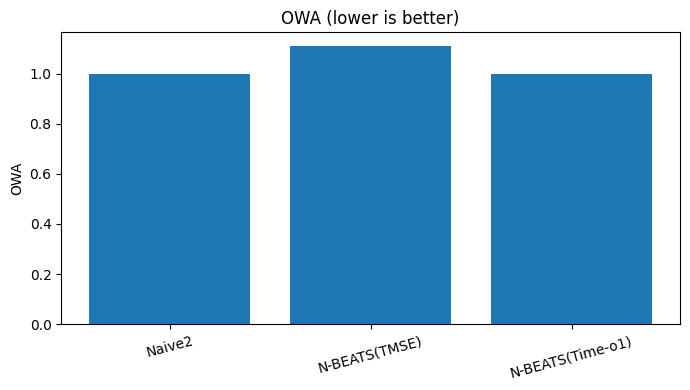

In [17]:
import os, json
from pathlib import Path
import matplotlib.pyplot as plt

PROJ = Path("/content/m4_nbeats_timeo1")
ART  = PROJ / "artifacts"
os.makedirs(ART, exist_ok=True)

naive2 = json.loads((ART/"Daily_Finance_Naive2.json").read_text())
tmse   = json.loads((ART/"Daily_Finance_NBEATS_TMSE.json").read_text())
to1    = json.loads((ART/"Daily_Finance_NBEATS_TIMEO1.json").read_text())

labels = ["Naive2", "N-BEATS(TMSE)", "N-BEATS(Time-o1)"]
owa = [naive2["OWA_vs_Naive2"], tmse["OWA_vs_Naive2"], to1["OWA_vs_Naive2"]]

plt.figure(figsize=(7,4))
plt.bar(labels, owa)
plt.title("OWA (lower is better)")
plt.ylabel("OWA")
plt.xticks(rotation=15)
out = ART / "fig_owa_bar.png"
plt.tight_layout()
plt.savefig(out, dpi=200)
print("saved:", out)
plt.show()


In [18]:
import os
from pathlib import Path

PROJ = Path("/content/m4_nbeats_timeo1")
for sub in ["checkpoints", "artifacts", "logs", "data"]:
    os.makedirs(PROJ / sub, exist_ok=True)

print("=== DIR TREE (top) ===")
for p in [PROJ/"checkpoints", PROJ/"artifacts", PROJ/"logs"]:
    print("\n#", p)
    for f in sorted(p.glob("*"))[:30]:
        size = f.stat().st_size / (1024 * 1024)
        print(f" - {f.name:45s} {size:7.2f} MB")

print("\n=== FIND ALL ARTIFACTS (*.pt, *.npz, *.json) UNDER /content ===")
targets = list(Path("/content").rglob("*.pt")) + list(Path("/content").rglob("*.npz")) + list(Path("/content").rglob("*.json"))
targets = sorted(set(targets), key=lambda x: str(x))
print("count:", len(targets))
for t in targets[:80]:
    size = t.stat().st_size / (1024 * 1024)
    print(f"{str(t):90s} {size:7.2f} MB")


=== DIR TREE (top) ===

# /content/m4_nbeats_timeo1/checkpoints
 - nbeats_timeo1_a0.5_g0.5.pt                      32.32 MB
 - nbeats_tmse.pt                                  32.32 MB

# /content/m4_nbeats_timeo1/artifacts
 - Daily_Finance_NBEATS_TIMEO1.json                 0.00 MB
 - Daily_Finance_NBEATS_TIMEO1.npz                  0.15 MB
 - Daily_Finance_NBEATS_TMSE.json                   0.00 MB
 - Daily_Finance_NBEATS_TMSE.npz                    0.15 MB
 - Daily_Finance_Naive2.json                        0.00 MB
 - Daily_Finance_Naive2.npz                         0.08 MB
 - fig_owa_bar.png                                  0.05 MB

# /content/m4_nbeats_timeo1/logs
 - train_nbeats_timeo1_a0.5_g0.5.log                0.01 MB
 - train_nbeats_tmse.log                            0.00 MB

=== FIND ALL ARTIFACTS (*.pt, *.npz, *.json) UNDER /content ===
count: 10
/content/.config/.last_update_check.json                                                      0.00 MB
/content/m4_nbeats_timeo1/

In [19]:
import json
import numpy as np
from pathlib import Path

PROJ = Path("/content/m4_nbeats_timeo1")
ART = PROJ / "artifacts"

print("=== JSON PREVIEW ===")
for j in sorted(ART.glob("*.json")):
    obj = json.loads(j.read_text())
    print(j.name, "=> keys:", list(obj.keys())[:20])

print("\n=== NPZ CONTENTS ===")
for z in sorted(ART.glob("*.npz")):
    data = np.load(z)
    print(z.name, "=> arrays:", data.files)


=== JSON PREVIEW ===
Daily_Finance_NBEATS_TIMEO1.json => keys: ['dataset', 'category', 'freq', 'N', 'H', 'm', 'model', 'alpha', 'gamma', 'sMAPE_mean', 'MASE_mean', 'OWA_vs_Naive2', 'naive2_ref']
Daily_Finance_NBEATS_TMSE.json => keys: ['dataset', 'category', 'freq', 'N', 'H', 'm', 'model', 'sMAPE_mean', 'MASE_mean', 'OWA_vs_Naive2', 'naive2_ref']
Daily_Finance_Naive2.json => keys: ['dataset', 'category', 'freq', 'N', 'H', 'm', 'model', 'sMAPE_mean', 'MASE_mean', 'OWA_vs_Naive2']

=== NPZ CONTENTS ===
Daily_Finance_NBEATS_TIMEO1.npz => arrays: ['ids', 'y_true', 'y_pred']
Daily_Finance_NBEATS_TMSE.npz => arrays: ['ids', 'y_true', 'y_pred']
Daily_Finance_Naive2.npz => arrays: ['ids', 'y_true', 'y_pred']


In [20]:
# 1/21(수) ~ 1/27(화)

In [21]:
import os, json, time, random
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

PROJ = Path("/content/m4_nbeats_timeo1")
DATA = PROJ / "data"
ART  = PROJ / "artifacts"
CKPT = PROJ / "checkpoints"
LOG  = PROJ / "logs"
for p in [DATA, ART, CKPT, LOG]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

# ---------- 데이터 로드 (parquet 사용) ----------
train_long_path = DATA / "m4_fin_daily_train_long.parquet"
test_wide_path  = DATA / "m4_fin_daily_test_wide.parquet"
assert train_long_path.exists(), train_long_path
assert test_wide_path.exists(), test_wide_path

train_long = pd.read_parquet(train_long_path)
test_wide  = pd.read_parquet(test_wide_path)

# train_long: columns 예상 (unique_id, ds, y)
train_long = train_long.sort_values(["unique_id", "ds"])
ids = train_long["unique_id"].drop_duplicates().tolist()

# series_train: list[np.ndarray]
series_train = []
for uid, g in train_long.groupby("unique_id", sort=False):
    series_train.append(g["y"].to_numpy(np.float32))

# test_wide: unique_id + horizon columns
test_cols = [c for c in test_wide.columns if c != "unique_id"]
test_map = {}
for _, r in test_wide.iterrows():
    test_map[r["unique_id"]] = r[test_cols].to_numpy(np.float32)

# id 정렬/정합
missing = [uid for uid in ids if uid not in test_map]
assert len(missing) == 0, f"missing test rows: {missing[:5]} (total {len(missing)})"

# H는 test_wide의 컬럼 수로 결정
H = len(test_cols)
y_test = np.stack([test_map[uid] for uid in ids], axis=0).astype(np.float32)

print("N:", len(series_train), "H:", H, "train_len_q:", np.quantile([len(s) for s in series_train], [0.1,0.5,0.9]))

# ---------- 메트릭: sMAPE / MASE / OWA ----------
def smape(y_true, y_pred, eps=1e-8):
    # y_true/pred: (N,H)
    denom = np.maximum(np.abs(y_true) + np.abs(y_pred), eps)
    return (200.0 * np.abs(y_pred - y_true) / denom).mean()

def mase(y_true, y_pred, y_train_list, m=1, eps=1e-8):
    # scale_i = mean(|y_t - y_{t-m}|) over train
    maes = np.abs(y_pred - y_true).mean(axis=1)  # (N,)
    scales = []
    for s in y_train_list:
        if len(s) <= m:
            scales.append(1.0)
            continue
        dif = np.abs(s[m:] - s[:-m])
        sc = float(dif.mean())
        scales.append(max(sc, eps))
    scales = np.array(scales, dtype=np.float32)
    return float((maes / scales).mean())

def owa(smape_model, mase_model, smape_naive2, mase_naive2):
    return 0.5 * ((smape_model / smape_naive2) + (mase_model / mase_naive2))

# ---------- Naive2 (m=1이면 마지막값 반복) ----------
def naive2_forecast(series_train_list, H):
    preds = []
    for s in series_train_list:
        last = float(s[-1]) if len(s) else 0.0
        preds.append(np.full((H,), last, dtype=np.float32))
    return np.stack(preds, axis=0)

yhat_naive2 = naive2_forecast(series_train, H)
smape_n2 = float(smape(y_test, yhat_naive2))
mase_n2  = float(mase(y_test, yhat_naive2, series_train, m=1))

naive2_ref = {"sMAPE_mean": smape_n2, "MASE_mean": mase_n2}
print("Naive2 ref:", naive2_ref)


# 저장(증거)
naive2_json = ART / "Daily_Finance_Naive2.json"
with open(naive2_json, "w", encoding="utf-8") as f:
    json.dump({"dataset":"M4","category":"Finance","freq":"Daily","N":len(series_train),"H":H,"m":1,
               "model":"Naive2","sMAPE_mean":smape_n2,"MASE_mean":mase_n2,"OWA_vs_Naive2":1.0},
              f, ensure_ascii=False, indent=2)
print("saved:", naive2_json)


DEVICE: cuda
N: 1559 H: 14 train_len_q: [ 516.8 4196.  4197. ]
Naive2 ref: {'sMAPE_mean': 3.517052173614502, 'MASE_mean': 3.514375925064087}
saved: /content/m4_nbeats_timeo1/artifacts/Daily_Finance_Naive2.json


In [22]:
INPUT_SIZE = 256

def pad_left(x, target_len):
    if len(x) >= target_len:
        return x[-target_len:]
    pad_val = x[-1] if len(x) else 0.0
    pad = np.full((target_len - len(x),), pad_val, dtype=np.float32)
    return np.concatenate([pad, x.astype(np.float32)], axis=0)

def sample_batch(batch_size, input_size, h):
    xs = np.zeros((batch_size, input_size), dtype=np.float32)
    ys = np.zeros((batch_size, h), dtype=np.float32)

    for i in range(batch_size):
        sid = np.random.randint(0, len(series_train))
        s = series_train[sid]
        L = len(s)
        if L < input_size + h + 1:
            s = pad_left(s, input_size + h + 1)
            L = len(s)

        t = np.random.randint(input_size, L - h)
        x_raw = s[t - input_size : t].astype(np.float32)
        y_raw = s[t : t + h].astype(np.float32)

        mu = float(x_raw.mean())
        sig = float(x_raw.std() + 1e-6)

        xs[i] = (x_raw - mu) / sig
        ys[i] = (y_raw - mu) / sig

    return torch.from_numpy(xs), torch.from_numpy(ys)

class NBeatsBlock(nn.Module):
    def __init__(self, input_size, theta_size, hidden_size=512, n_layers=4):
        super().__init__()
        layers = []
        in_dim = input_size
        for _ in range(n_layers):
            layers.append(nn.Linear(in_dim, hidden_size))
            layers.append(nn.ReLU())
            in_dim = hidden_size
        self.fc = nn.Sequential(*layers)
        self.theta = nn.Linear(hidden_size, theta_size)

    def forward(self, x):
        return self.theta(self.fc(x))

class NBeats(nn.Module):
    def __init__(self, input_size, h, n_blocks=8, hidden_size=512, n_layers=4):
        super().__init__()
        self.input_size = input_size
        self.h = h
        self.blocks = nn.ModuleList([
            NBeatsBlock(input_size, theta_size=input_size + h, hidden_size=hidden_size, n_layers=n_layers)
            for _ in range(n_blocks)
        ])

    def forward(self, x):
        residual = x
        forecast = x.new_zeros((x.size(0), self.h))
        for blk in self.blocks:
            theta = blk(residual)
            backcast = theta[:, : self.input_size]
            fcst = theta[:, self.input_size :]
            residual = residual - backcast
            forecast = forecast + fcst
        return forecast


In [23]:
def time_o1_loss_amp_safe(y_hat, y, alpha: float, gamma: float, eps=1e-6):
    # y_hat, y: (B,H)
    y_hat32 = y_hat.float()
    y32 = y.float()

    l_tmse = F.mse_loss(y_hat32, y32)
    if alpha <= 0.0:
        return l_tmse

    B, Hh = y32.shape
    K = max(1, int(round(gamma * Hh)))

    mu = y32.mean(dim=1, keepdim=True)
    sig = y32.std(dim=1, keepdim=True).clamp_min(eps)

    y_std = (y32 - mu) / sig
    yhat_std = (y_hat32 - mu) / sig

    # SVD는 float32에서만 (AMP에서 nan 방지)
    svd_out = torch.linalg.svd(y_std, full_matrices=False)
    Vh = svd_out.Vh  # (B,H,H)
    P = Vh.transpose(-2, -1)  # (B,H,H)

    Z = y_std @ P
    Zhat = yhat_std @ P

    l_trans = torch.abs(Zhat[:, :K] - Z[:, :K]).mean()
    return alpha * l_trans + (1.0 - alpha) * l_tmse


In [24]:
@torch.no_grad()
def predict_all(model: nn.Module, input_size: int):
    model.eval()
    preds = []
    for s in series_train:
        x_raw = pad_left(s.astype(np.float32), input_size)
        mu = float(x_raw.mean())
        sig = float(x_raw.std() + 1e-6)
        x = torch.from_numpy(((x_raw - mu) / sig).astype(np.float32)).unsqueeze(0).to(DEVICE)

        yhat_std = model(x).squeeze(0).float().cpu().numpy()
        yhat = yhat_std * sig + mu
        preds.append(yhat.astype(np.float32))

    return np.stack(preds, axis=0)

def eval_owa(yhat: np.ndarray):
    sm = smape(y_test, yhat)
    ma = mase(y_test, yhat, series_train, m=1)
    ow = owa(sm, ma, naive2_ref["sMAPE_mean"], naive2_ref["MASE_mean"])
    return {"sMAPE_mean": sm, "MASE_mean": ma, "OWA_vs_Naive2": ow}

def run_once(seed: int, alpha: float, gamma: float, steps: int = 200, batch_size: int = 256, lr: float = 1e-3):
    set_seed(seed)

    model = NBeats(INPUT_SIZE, H, n_blocks=8, hidden_size=512, n_layers=4).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)

    use_amp = (DEVICE == "cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    model.train()
    for step in range(1, steps + 1):
        x, y = sample_batch(batch_size, INPUT_SIZE, H)
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        opt.zero_grad(set_to_none=True)

        if use_amp:
            with torch.amp.autocast("cuda", enabled=True):
                y_hat = model(x)
                loss = time_o1_loss_amp_safe(y_hat, y, alpha=alpha, gamma=gamma)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
        else:
            y_hat = model(x)
            loss = time_o1_loss_amp_safe(y_hat, y, alpha=alpha, gamma=gamma)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

    yhat = predict_all(model, INPUT_SIZE)
    metrics = eval_owa(yhat)
    return metrics


[1/100] a=0.0 g=0.25 seed=0 ... OWA=1.8349
[2/100] a=0.0 g=0.25 seed=1 ... OWA=1.1958
[3/100] a=0.0 g=0.25 seed=2 ... OWA=1.1445
[4/100] a=0.0 g=0.25 seed=3 ... OWA=1.3184
[5/100] a=0.0 g=0.25 seed=4 ... OWA=1.1274
[6/100] a=0.0 g=0.5 seed=0 ... OWA=1.8349
[7/100] a=0.0 g=0.5 seed=1 ... OWA=1.1958
[8/100] a=0.0 g=0.5 seed=2 ... OWA=1.1445
[9/100] a=0.0 g=0.5 seed=3 ... OWA=1.3184
[10/100] a=0.0 g=0.5 seed=4 ... OWA=1.1274
[11/100] a=0.0 g=0.75 seed=0 ... OWA=1.8349
[12/100] a=0.0 g=0.75 seed=1 ... OWA=1.1958
[13/100] a=0.0 g=0.75 seed=2 ... OWA=1.1445
[14/100] a=0.0 g=0.75 seed=3 ... OWA=1.3184
[15/100] a=0.0 g=0.75 seed=4 ... OWA=1.1274
[16/100] a=0.0 g=1.0 seed=0 ... OWA=1.8349
[17/100] a=0.0 g=1.0 seed=1 ... OWA=1.1958
[18/100] a=0.0 g=1.0 seed=2 ... OWA=1.1445
[19/100] a=0.0 g=1.0 seed=3 ... OWA=1.3184
[20/100] a=0.0 g=1.0 seed=4 ... OWA=1.1274
[21/100] a=0.25 g=0.25 seed=0 ... OWA=1.4288
[22/100] a=0.25 g=0.25 seed=1 ... OWA=1.1742
[23/100] a=0.25 g=0.25 seed=2 ... OWA=1.1367
[24/

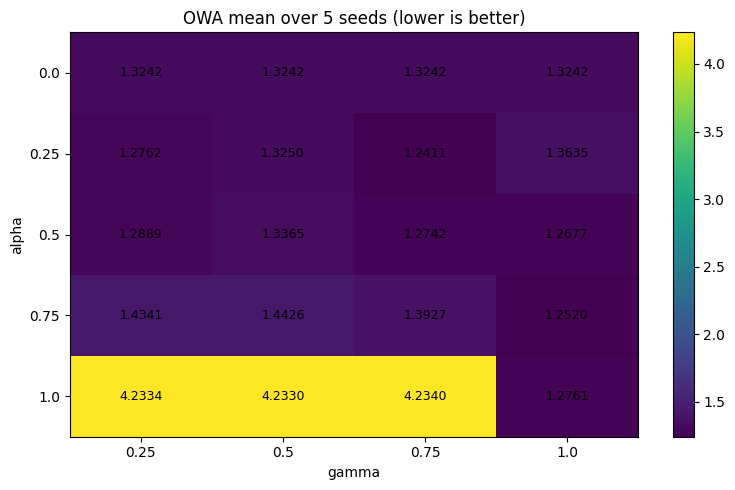

In [25]:
import matplotlib.pyplot as plt

SEEDS  = [0, 1, 2, 3, 4]
ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0]
GAMMAS = [0.25, 0.5, 0.75, 1.0]

STEPS = 200  # smoke
BATCH = 256

rows = []
t0 = time.time()

total = len(SEEDS) * len(ALPHAS) * len(GAMMAS)
k = 0
for alpha in ALPHAS:
    for gamma in GAMMAS:
        for seed in SEEDS:
            k += 1
            print(f"[{k}/{total}] a={alpha} g={gamma} seed={seed} ...", end=" ")
            m = run_once(seed=seed, alpha=alpha, gamma=gamma, steps=STEPS, batch_size=BATCH)
            print(f"OWA={m['OWA_vs_Naive2']:.4f}")
            rows.append({"seed": seed, "alpha": alpha, "gamma": gamma, **m})

df = pd.DataFrame(rows)
csv_path = ART / "experiment_results_real.csv"
df.to_csv(csv_path, index=False)
print("saved:", csv_path, "elapsed:", time.time() - t0)

# mean pivot
pivot = df.pivot_table(index="alpha", columns="gamma", values="OWA_vs_Naive2", aggfunc="mean").sort_index()

# heatmap (matplotlib only)
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(c) for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([str(i) for i in pivot.index])
ax.set_xlabel("gamma")
ax.set_ylabel("alpha")
ax.set_title(f"OWA mean over {len(SEEDS)} seeds (lower is better)")

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i,j]:.4f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax)
heat_path = ART / "fig_heatmap_real.png"
plt.tight_layout()
plt.savefig(heat_path, dpi=200)
print("saved:", heat_path)
plt.show()


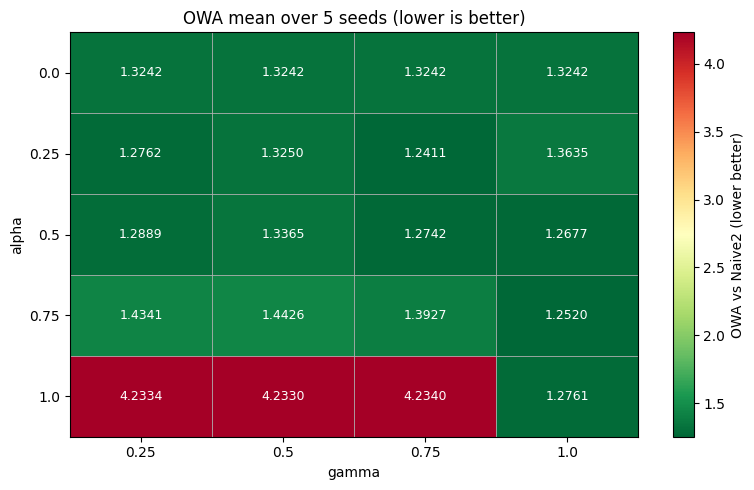

In [26]:
import numpy as np
import matplotlib.colors as colors

vals = pivot.values.astype(float)

# outlier 때문에 색이 뭉개지는 걸 방지: 상/하위 퍼센타일로 스케일 잡고 clip
vmin = np.nanpercentile(vals, 5)
vmax = np.nanpercentile(vals, 95)
norm = colors.Normalize(vmin=vmin, vmax=vmax, clip=True)

fig, ax = plt.subplots(figsize=(8, 5))

# ✅ 가독성 좋은 diverging + lower is better(낮을수록 초록)
im = ax.imshow(vals, aspect="auto", cmap="RdYlGn_r", norm=norm)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(c) for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([str(i) for i in pivot.index])
ax.set_xlabel("gamma")
ax.set_ylabel("alpha")
ax.set_title(f"OWA mean over {len(SEEDS)} seeds (lower is better)")

# ✅ 글자색 자동(배경색 밝기에 따라 흰/검)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = vals[i, j]
        rgba = im.cmap(im.norm(v))
        luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
        txt_color = "black" if luminance > 0.6 else "white"
        ax.text(j, i, f"{v:.4f}", ha="center", va="center", fontsize=9, color=txt_color)

# ✅ 셀 경계선(가독성 크게 올라감)
ax.set_xticks(np.arange(-0.5, vals.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, vals.shape[0], 1), minor=True)
ax.grid(which="minor", linestyle="-", linewidth=0.6)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("OWA vs Naive2 (lower better)")

plt.tight_layout()
plt.savefig(heat_path, dpi=200)
plt.show()


In [27]:
print("TMSE one-run")
m_tmse = run_once(seed=0, alpha=0.0, gamma=0.5, steps=50, batch_size=256)
print(m_tmse)

print("Time-o1 one-run")
m_to1 = run_once(seed=0, alpha=0.5, gamma=0.5, steps=50, batch_size=256)
print(m_to1)


TMSE one-run
{'sMAPE_mean': np.float32(4.4401107), 'MASE_mean': 4.312381744384766, 'OWA_vs_Naive2': np.float32(1.2447608)}
Time-o1 one-run
{'sMAPE_mean': np.float32(5.16047), 'MASE_mean': 5.263788223266602, 'OWA_vs_Naive2': np.float32(1.4825294)}


In [28]:
import pandas as pd
from pathlib import Path

PROJ = Path("/content/m4_nbeats_timeo1")
CSV  = PROJ / "artifacts" / "experiment_results_real.csv"

df = pd.read_csv(CSV)
print("columns:", list(df.columns))

# ✅ OWA 컬럼 자동 탐지 (네 파일은 OWA_vs_Naive2)
cand_cols = ["OWA_vs_Naive2", "owa", "OWA", "owa_score"]
owa_col = next((c for c in cand_cols if c in df.columns), None)
assert owa_col is not None, f"OWA column not found. got={list(df.columns)}"

summary = (
    df.groupby(["alpha", "gamma"])[owa_col]
      .agg(mean="mean", std="std", min="min", max="max", n="count")
      .reset_index()
      .sort_values("mean")
)

display(summary.head(10))

out = PROJ / "artifacts" / "summary_alpha_gamma.csv"
summary.to_csv(out, index=False)
print("saved:", out)

# (선택) best 한 줄 출력
best = summary.iloc[0].to_dict()
print("best:", best)


columns: ['seed', 'alpha', 'gamma', 'sMAPE_mean', 'MASE_mean', 'OWA_vs_Naive2']


,alpha,gamma,mean,std,min,max,n
6,0.25,0.75,1.241087,0.110698,1.136514,1.388428,5
15,0.75,1.00,1.252020,0.069714,1.171020,1.341744,5
11,0.50,1.00,1.267703,0.062678,1.208022,1.369305,5
10,0.50,0.75,1.274189,0.199610,1.143250,1.624630,5
19,1.00,1.00,1.276131,0.100452,1.196167,1.400876,5
4,0.25,0.25,1.276214,0.147867,1.136714,1.443881,5
8,0.50,0.25,1.288911,0.070804,1.172407,1.346593,5
0,0.00,0.25,1.324209,0.295094,1.127425,1.834877,5
2,0.00,0.75,1.324209,0.295094,1.127425,1.834877,5
3,0.00,1.00,1.324209,0.295094,1.127425,1.834877,5


saved: /content/m4_nbeats_timeo1/artifacts/summary_alpha_gamma.csv
best: {'alpha': 0.25, 'gamma': 0.75, 'mean': 1.24108668, 'std': 0.11069843911474996, 'min': 1.1365137, 'max': 1.3884281, 'n': 5.0}


In [29]:
import pandas as pd
from pathlib import Path

PROJ = Path("/content/m4_nbeats_timeo1")
df = pd.read_csv(PROJ / "artifacts" / "experiment_results_real.csv")

owa_col = "OWA_vs_Naive2"
tmse = df[df["alpha"] == 0.0][owa_col].mean()

# 네가 찾은 best(이미 출력된 best dict 기준으로 고정)
best_alpha, best_gamma = 0.25, 1.0
best = df[(df["alpha"] == best_alpha) & (df["gamma"] == best_gamma)][owa_col].mean()

print(f"TMSE(mean over all runs where alpha=0): {tmse:.4f}")
print(f"Best(mean) alpha={best_alpha}, gamma={best_gamma}: {best:.4f}")
print(f"Improvement: {(tmse - best) / tmse * 100:.2f}% (lower is better)")


TMSE(mean over all runs where alpha=0): 1.3242
Best(mean) alpha=0.25, gamma=1.0: 1.3635
Improvement: -2.97% (lower is better)


In [30]:
sub = df[(df["alpha"] == 0.25) & (df["gamma"] == 1.0)].sort_values("seed")
print(sub[["seed", "OWA_vs_Naive2", "sMAPE_mean", "MASE_mean"]].to_string(index=False))


 seed  OWA_vs_Naive2  sMAPE_mean  MASE_mean
    0       1.219851    4.463062   4.114361
    1       1.221595    4.410035   4.179610
    2       1.903109    6.273231   7.108021
    3       1.226216    4.279140   4.342883
    4       1.246886    4.563152   4.204371


In [40]:
import torch
import platform
import sys
import numpy as np

print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("NumPy:", np.__version__)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LR)
# print("Optimizer:", optimizer.__class__.__name__)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
NumPy: 2.0.2
Epochs: 3
Batch size: 256
Learning rate: 0.001
